# What are the most optimal skills to learn for Data Analysts

In [17]:
#importing libraries
import ast
import pandas as pd
import seaborn as sns 
from adjustText import adjust_text
from datasets import load_dataset
import matplotlib.pyplot as plt
from matplotlib.ticker import PercentFormatter

#loading data 
dataset=load_dataset('lukebarousse/data_jobs')
df = dataset['train'].to_pandas()


#Data Cleanup
df['job_posted_date']= pd.to_datetime(df['job_posted_date'])
df['job_skills']= df['job_skills'].apply(lambda x: ast.literal_eval(x) if pd.notna(x) else x)

In [4]:
df_Da_US=df[(df['job_title_short']== 'Data Analyst') & (df['job_country']=='United States')].copy()
df_Da_US = df_Da_US.dropna(subset=['salary_year_avg'])

df_Da_US_exploded = df_Da_US.explode('job_skills')
df_Da_US_exploded[['salary_year_avg','job_skills']].head(5)


,salary_year_avg,job_skills
109,89000.0,python
109,89000.0,r
109,89000.0,alteryx
109,89000.0,tableau
180,90250.0,excel


In [9]:

df_DA_skills=df_Da_US_exploded.groupby('job_skills')['salary_year_avg'].agg(['count','median']).sort_values(by='count',ascending=False)

df_DA_skills=df_DA_skills.rename(columns={'count':'skill_count', 'median':'median_salary'})

df_DA_skills


,skill_count,median_salary
job_skills,,
sql,2508,91000.0
excel,1808,84392.0
python,1431,97500.0
tableau,1364,92875.0
sas,926,90000.0
...,...,...
theano,1,100000.0
typescript,1,65000.0
vmware,1,147500.0


In [11]:
DA_job_count = len(df_Da_US)

df_DA_skills['skill_percent'] =df_DA_skills['skill_count']/ DA_job_count * 100
skill_percent = 5

df_DA_skills_high_demand = df_DA_skills[df_DA_skills['skill_percent'] > skill_percent]
df_DA_skills_high_demand


,skill_count,median_salary,skill_percent
job_skills,,,
sql,2508,91000.00,57.655172
excel,1808,84392.00,41.563218
python,1431,97500.00,32.896552
tableau,1364,92875.00,31.356322
sas,926,90000.00,21.287356
r,893,92500.00,20.528736
power bi,838,90000.00,19.264368
powerpoint,462,85000.00,10.620690
word,461,81194.75,10.597701


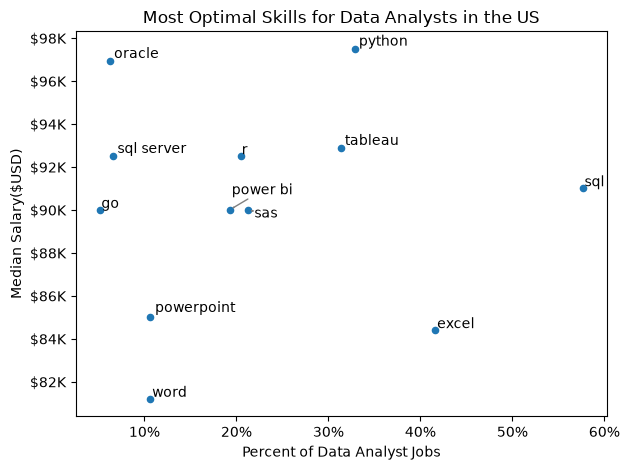

In [ ]:

df_DA_skills_high_demand.plot(kind='scatter', x='skill_percent', y='median_salary')
#create empty list
texts=[]

for i, txt in enumerate(df_DA_skills_high_demand.index):                   #for adding titles to scatter plot points
  texts.append(
    plt.text(
      df_DA_skills_high_demand['skill_percent'].iloc[i],
      df_DA_skills_high_demand['median_salary'].iloc[i],
      txt
      )
    )
#adjust all text
adjust_text(
  texts,
    arrowprops=dict(
        arrowstyle="->",
        color='gray',
        lw=1
    )
    )

ax=plt.gca()
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, pos : f'${int(y/1000)}K'))
ax.xaxis.set_major_formatter(PercentFormatter(decimals=0))
plt.xlabel('Percent of Data Analyst Jobs')
plt.ylabel('Median Salary($USD)')
plt.title( 'Most Optimal Skills for Data Analysts in the US')
plt.tight_layout() 
plt.show()

In [21]:
df_technology=df['job_type_skills'].copy()

 #remove duplicates
df_technology = df_technology.drop_duplicates()   

# remove NAN values
df_technology = df_technology.dropna()

#combine all dictionaries into one 
technology_dict={}
for row in df_technology:
    row_dict= ast.literal_eval(row) # convert string to dictionary
    for key, value in row_dict.items():
        if key in technology_dict:  # if key already exists in technology_dict , add value to existing key 
            technology_dict[key]+= value        
        else:                       # if key does not exist in technology_dict, add key and value  
             technology_dict[key]= value      \

 # remove duplicates by converting values to set them back to the list
for key, value in technology_dict.items():
    technology_dict[key] = list(set(value))

technology_dict

{'analyst_tools': ['spreadsheet',
  'splunk',
  'excel',
  'power bi',
  'microstrategy',
  'dax',
  'visio',
  'msaccess',
  'powerpoint',
  'esquisse',
  'spss',
  'ssis',
  'datarobot',
  'ssrs',
  'powerbi',
  'sas',
  'alteryx',
  'nuix',
  'ms access',
  'sheets',
  'sap',
  'outlook',
  'sharepoint',
  'word',
  'tableau',
  'looker',
  'qlik',
  'cognos'],
 'programming': ['matlab',
  'c++',
  'vb.net',
  'html',
  'c#',
  'cobol',
  'julia',
  'visual basic',
  'fortran',
  'groovy',
  'nosql',
  'perl',
  'haskell',
  'elixir',
  'kotlin',
  'erlang',
  'scala',
  'php',
  'apl',
  'mongo',
  'sql',
  'sass',
  'sas',
  'bash',
  'powershell',
  'javascript',
  'typescript',
  'go',
  'c',
  'shell',
  'assembly',
  'no-sql',
  'ocaml',
  'swift',
  'mongodb',
  'ruby',
  'objective-c',
  'visualbasic',
  'python',
  'java',
  'solidity',
  'pascal',
  't-sql',
  'clojure',
  'lua',
  'vba',
  'golang',
  'crystal',
  'dart',
  'css',
  'delphi',
  'lisp',
  'rust',
  'f#',
 

In [24]:
df_technology= pd.DataFrame(list(technology_dict.items()),columns=['technology','skills'])

df_technology = df_technology.explode('skills')
df_technology

,technology,skills
0,analyst_tools,spreadsheet
0,analyst_tools,splunk
0,analyst_tools,excel
0,analyst_tools,power bi
0,analyst_tools,microstrategy
...,...,...
9,sync,rocketchat
9,sync,unify
9,sync,symphony
9,sync,slack


In [26]:
df_plot=df_DA_skills_high_demand.merge(df_technology, left_on='job_skills', right_on='skills')

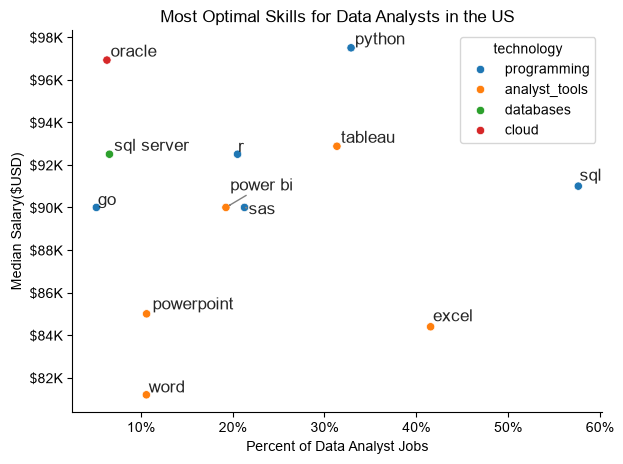

In [29]:
#df_plot.plot(kind='scatter', x='skill_percent', y='median_salary')
sns.scatterplot(
data=df_plot,
x='skill_percent',
y='median_salary',
hue='technology' 
                )

sns.despine()
sns.set_theme(style='ticks')
#create empty list
texts=[]

for i, txt in enumerate(df_DA_skills_high_demand.index):                   #for adding titles to scatter plot points
  texts.append(
    plt.text(
      df_DA_skills_high_demand['skill_percent'].iloc[i],
      df_DA_skills_high_demand['median_salary'].iloc[i],
      txt
      )
    )
#adjust all text
adjust_text(
  texts,
    arrowprops=dict(
        arrowstyle="->",
        color='gray',
        lw=1
    )
    )

ax=plt.gca()
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, pos : f'${int(y/1000)}K'))
ax.xaxis.set_major_formatter(PercentFormatter(decimals=0))
plt.xlabel('Percent of Data Analyst Jobs')
plt.ylabel('Median Salary($USD)')
plt.title( 'Most Optimal Skills for Data Analysts in the US')
plt.tight_layout() 
plt.show()